## Preparación de datos

El servicio de venta de autos usados Rusty Bargain está desarrollando una aplicación para atraer nuevos clientes. Gracias a esa app, puedes averiguar rápidamente el valor de mercado de tu coche. Tienes acceso al historial: especificaciones técnicas, versiones de equipamiento y precios. Tienes que crear un modelo que determine el valor de mercado.
A Rusty Bargain le interesa:
- la calidad de la predicción;
- la velocidad de la predicción;
- el tiempo requerido para el entrenamiento

### Inicialización

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import re
import time
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML
import matplotlib.pyplot as plt

### Carga de datos

In [47]:
df = pd.read_csv('car_data.csv')

print(f'Duplicados : {df.duplicated().sum()}\n')
df.info()
df.head()

Duplicados : 262

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes:

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


<div class="alert alert-block" style="background-color: #eceeef; color: black;">
Se reemplazarán los valores 'no' y 'yes' de a columna <span style="background-color: #d3d3d3;">not_repaired</span> por valores 0 y 1 respectivamente, para un manejo adecuado en el entrenamiento del modelo. Los valores ausentes se tomarán como 0.

Se eliminarán las filas duplicadas. Por cuestiones de preferencia, se modificará el estilo de las columnas de PascalCase a snake_case.
    <a class=“tocSkip”></a>
</div>

In [48]:
def snake(name):
    return re.sub(r'(?<!^)(?=[A-Z])', '_', name).lower()

df.columns = [snake(col) for col in df.columns]

df['not_repaired'] = (df['not_repaired'].astype('object').replace({'yes': 1, 'no': 0}).fillna(0).astype(int))


df = df.drop_duplicates()

print(f'Duplicados : {df.duplicated().sum()}\n')
df.info()
df.head()

C:\Users\paula\AppData\Local\Temp\ipykernel_15728\2639190105.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['not_repaired'] = (df['not_repaired'].astype('object').replace({'yes': 1, 'no': 0}).fillna(0).astype(int))


Duplicados : 0

<class 'pandas.core.frame.DataFrame'>
Index: 354078 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   date_crawled        354078 non-null  object
 1   price               354078 non-null  int64 
 2   vehicle_type        316594 non-null  object
 3   registration_year   354078 non-null  int64 
 4   gearbox             334248 non-null  object
 5   power               354078 non-null  int64 
 6   model               334377 non-null  object
 7   mileage             354078 non-null  int64 
 8   registration_month  354078 non-null  int64 
 9   fuel_type           321189 non-null  object
 10  brand               354078 non-null  object
 11  not_repaired        354078 non-null  int64 
 12  date_created        354078 non-null  object
 13  number_of_pictures  354078 non-null  int64 
 14  postal_code         354078 non-null  int64 
 15  last_seen           354078 non-null  obj

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,number_of_pictures,postal_code,last_seen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,0,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,1,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,0,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,0,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,0,31/03/2016 00:00,0,60437,06/04/2016 10:17


In [49]:
df.describe(include='all')

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,number_of_pictures,postal_code,last_seen
count,354078,354078.000000,316594,354078.000000,334248,354078.000000,334377,354078.000000,354078.000000,321189,354078,354078.000000,354078,354078.0,354078.000000,354078
unique,15470,NaN,8,NaN,2,NaN,250,NaN,NaN,7,40,NaN,109,NaN,NaN,18592
top,05/03/2016 14:25,NaN,sedan,NaN,manual,NaN,golf,NaN,NaN,petrol,volkswagen,NaN,03/04/2016 00:00,NaN,NaN,07/04/2016 07:16
freq,66,NaN,91387,NaN,268008,NaN,29214,NaN,NaN,216140,76955,NaN,13702,NaN,NaN,653
mean,NaN,4416.438036,NaN,2004.235584,NaN,110.088187,NaN,128211.128621,5.714114,NaN,NaN,0.101771,NaN,0.0,50506.726024,NaN
std,NaN,4514.383690,NaN,90.264848,NaN,189.921951,NaN,37907.094795,3.726686,NaN,NaN,0.302348,NaN,0.0,25784.378869,NaN
min,NaN,0.000000,NaN,1000.000000,NaN,0.000000,NaN,5000.000000,0.000000,NaN,NaN,0.000000,NaN,0.0,1067.000000,NaN
25%,NaN,1050.000000,NaN,1999.000000,NaN,69.000000,NaN,125000.000000,3.000000,NaN,NaN,0.000000,NaN,0.0,30165.000000,NaN
50%,NaN,2700.000000,NaN,2003.000000,NaN,105.000000,NaN,150000.000000,6.000000,NaN,NaN,0.000000,NaN,0.0,49406.000000,NaN
75%,NaN,6400.000000,NaN,2008.000000,NaN,143.000000,NaN,150000.000000,9.000000,NaN,NaN,0.000000,NaN,0.0,71083.000000,NaN


**Analizando las variables**

<div class="alert alert-block" style="background-color: #eceeef; color: black;">

* price: tiene un valor mínimo de 0 y máximo de 2000, el 75% es de 6400, lo cual indica que valores fuera de este rango podrían ser outliers. La media es $\approx$ 4416 y la desviación estándar de $\approx$ 4514, esta última nos indica una alta dispersión. Lo más probable es que los valores 0 no sean reales por lo que se eliminaran, más adelante se determinará si es necesario eliminar outliers.

* vehicle_type: hay 8 modelos, siendo el sedan el más frecuente (28.87%), tiene un 10.6% de valores faltantes que se rellenarán como 'unknown'.

* registration_year: tiene un valor mínimo de 1000 y máximo de 9999, lo cual no es realista, por lo que se tomaran valores en un rango de 1950 < registration_year < 2024.

* gearbox: 2 tipos, manual y automático, siendo manual el más frecuente (80.18%), tiene un 5.6% de valores faltantes que se tomarán como 'unknown'.

* power: cuenta con un rango de 0 - 20000, esto es incorrecto, los valores comunes en carros pequeños es de 75 CV, uno familiar entre 110-200 CV, pero un automovil deportivo puede tener 500 CV, por lo que se tomará un rango de 75 - 500 CV.

* model: 250 modelos distintos, siendo el golf el más frecuente (8.74%), tiene $\approx$ 5.6% de valores faltantes que se tomarán como 'unknown'.

> model y gearbox, tienen aproximadamente el mismo porcentaje de valores faltantes, para tratar los valores ausentes, primero se eliminarán las filas que tiene valores faltantes en ambas columnas.

* mileage: rango de 5000 a 150000 con una media de $\approx$ 128 mil, parece que esta columna no necesita cambios.

* registration_month: rango de 0 a 12, el 0 puede ser debido a que el mes de matrícula no se proporcionó, por lo que es un valor ausente. Dicho lo anterior, se cambiará de 0 a NaN.

* fuel_type: cuenta con 9.2 % de valores faltantes que se tomarán como 'unknown'.

* date_crawled, model, registration_month, date_created, number_of_pictures, postal_code y last_seen, no aportan información reelevante para calcular el precio de los autos, por lo que ambas columnas se eliminarán.
    <a class=“tocSkip”></a>
</div>

#### Price

<div class="alert alert-block" style="background-color: #eceeef; color: black;">
Se tomará un rango razonable, donde el precio mínimo se considerará como \$800.
    <a class=“tocSkip”></a>
</div>

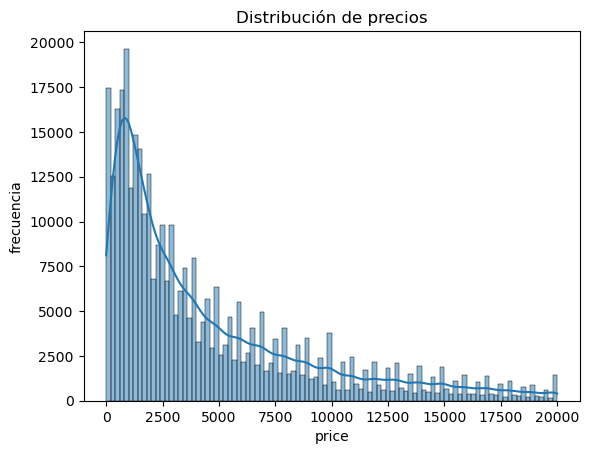

In [50]:
sns.histplot(df['price'], bins=100, kde=True)
plt.title('Distribución de precios')
plt.xlabel('price')
plt.ylabel('frecuencia')
plt.show()

In [51]:
low, high = df['price'].quantile([0.01, 0.99])
df_clean = df[(df['price'] > 800) & (df['price'] >= low) & (df['price'] <= high)]

In [52]:
print(f"   Original: {df.shape[0]} filas")
print(f"     Limpio: {df_clean.shape[0]} filas")

   Original: 354078 filas
     Limpio: 283214 filas


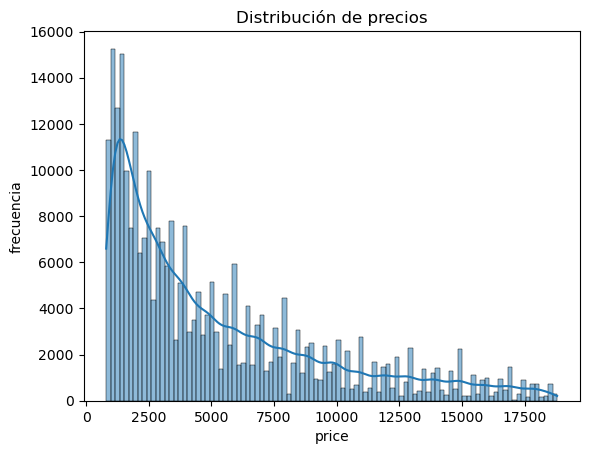

In [53]:
sns.histplot(df_clean['price'], bins=100, kde=True)
plt.title('Distribución de precios')
plt.xlabel('price')
plt.ylabel('frecuencia')
plt.show()

<div class="alert alert-block" style="background-color: #eceeef; color: black;">
Antes de sustituir los valores ausentes por 'unknown' en las columnas <span style="background-color: #d3d3d3;">vehicle_type</span>, <span style="background-color: #d3d3d3;">gearbox</span> y <span style="background-color: #d3d3d3;">fuel_type</span>, eliminaremos las filas donde los valores para estas 4 características son valores ausentes:
    <a class=“tocSkip”></a>
</div>

In [54]:
df_clean['vehicle_type'].isna().sum(), df_clean['gearbox'].isna().sum(), df_clean['fuel_type'].isna().sum()

(np.int64(22222), np.int64(11051), np.int64(19004))

In [55]:
df_clean[['vehicle_type', 'gearbox', 'fuel_type']].isna().all(axis=1).sum()

np.int64(2344)

In [56]:
df_clean = df_clean[~df_clean[['vehicle_type', 'gearbox', 'fuel_type']].isna().all(axis=1)]
df_clean[['vehicle_type', 'gearbox', 'fuel_type']].isna().all(axis=1).sum()

np.int64(0)

<div class="alert alert-block" style="background-color: #eceeef; color: black;">
Sustituyendo los valores ausentes de las columnas <span style="background-color: #d3d3d3;">vehicle_type</span>, <span style="background-color: #d3d3d3;">gearbox</span> y <span style="background-color: #d3d3d3;">fuel_type</span> por 'unknown'
    <a class=“tocSkip”></a>
</div>

In [57]:
name_cols = ['vehicle_type', 'gearbox', 'fuel_type']
df_clean[name_cols] = df_clean[name_cols].fillna('unknown')

#### Eliminar columnas

<div class="alert alert-block" style="background-color: #eceeef; color: black;">
<span style="background-color: #d3d3d3;">date_crawled</span>, <span style="background-color: #d3d3d3;">model</span>, <span style="background-color: #d3d3d3;">registration_month</span>, <span style="background-color: #d3d3d3;">date_created</span>, <span style="background-color: #d3d3d3;">number_of_pictures</span>, <span style="background-color: #d3d3d3;">postal_code</span>, <span style="background-color: #d3d3d3;">last_seen</span>
    <a class=“tocSkip”></a>
</div>

In [58]:
df_clean = df_clean.drop(['date_crawled', 'model', 'registration_month', 'date_created',
                          'number_of_pictures', 'postal_code', 'last_seen'], axis=1)

#### Registation year

<div class="alert alert-block" style="background-color: #eceeef; color: black;">
Tomando el rango 1950 - 2024.
    <a class=“tocSkip”></a>
</div>

In [59]:
df_clean = df_clean[(df_clean['registration_year'] > 1950) & (df_clean['registration_year'] < 2024)]

#### Power
<div class="alert alert-block" style="background-color: #eceeef; color: black;">
Tomando el rango 75 - 500 CV.
    <a class=“tocSkip”></a>
</div>

In [60]:
df_clean = df_clean[(df_clean['power'] > 75) & (df_clean['power'] < 500)]

## Entrenamiento del modelo 

In [61]:
# Encontrar las columnas categóricas
X = df_clean.drop('price', axis=1)
cat_cols = X.select_dtypes(include='object').columns
df_ohe = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

In [62]:
features = df_ohe.drop('price', axis=1)
target = df_ohe['price']

# Segmenta los datos para el entrenamiento (60%) y para las pruebas (40%)
features_train, features_inter, target_train, target_inter = train_test_split(
    features, target, test_size=0.4, random_state=12345)

# Segmenta los datos para la validación (20%) y para la prueba (20%)
features_valid, features_test, target_valid, target_test = train_test_split(
    features_inter, target_inter, test_size=0.5, random_state=12345)

In [63]:
print(f"{'Conjunto':<15} {'Features':<10} {'Target':<10}")
print("-" * 35)
print(f"{'Original':<15} {len(features):<10} {len(target):<10}")
print(f"{'Entrenamiento':<15} {len(features_train):<10} {len(target_train):<10}")
print(f"{'Validación':<15} {len(features_valid):<10} {len(target_valid):<10}")
print(f"{'Prueba':<15} {len(features_test):<10} {len(target_test):<10}")

Conjunto        Features   Target    
-----------------------------------
Original        205554     205554    
Entrenamiento   123332     123332    
Validación      41111      41111     
Prueba          41111      41111     


#### Regresión Lineal

In [64]:
import sys
sys.executable


'c:\\Users\\paula\\anaconda3\\envs\\vehicles_env\\python.exe'

In [65]:
%%time

lr = LinearRegression()
lr.fit(features_train, target_train)
predict_lr = lr.predict(features_valid)

mse_lr = mean_squared_error(target_valid, predict_lr)
rmse_lr = mse_lr ** 0.5

print(f'Regresión Lineal | RMSE: {rmse_lr:.2f}\n')

print(f'Regresión Lineal | RMSE: {rmse_lr:.2f}\n')

Regresión Lineal | RMSE: 2759.86

Regresión Lineal | RMSE: 2759.86

CPU times: total: 672 ms
Wall time: 270 ms


#### Árbol de decisión

In [66]:
%%time

tree = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 20]}

grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(features_train, target_train)

best_model_ad = grid_search.best_estimator_
best_params_ad = grid_search.best_params_

# Comparar conjunto de entrenamiento y validación
pred_train = best_model_ad.predict(features_train)
pred_valid = best_model_ad.predict(features_valid)
rmse_train = (mean_squared_error(target_train, pred_train))**0.5
rmse_valid = (mean_squared_error(target_valid, pred_valid))**0.5

print(f'Mejores hiperparámetros: {best_params_ad}')
print(f'RMSE | conjunto de entrenamiento: {rmse_train:.2f}')
print(f'RMSE | conjunto de validación:    {rmse_valid:.2f} \n')

Mejores hiperparámetros: {'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 20}
RMSE | conjunto de entrenamiento: 1598.08
RMSE | conjunto de validación:    1879.00 

CPU times: total: 3min 56s
Wall time: 4min 10s


#### Random Forest

In [67]:
%%time

forest = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators':[20],
    'max_depth': [20],
    'min_samples_leaf': [1, 5],
    'min_samples_split': [2, 10]}

grid_rf = GridSearchCV(forest, param_grid=param_grid_rf, scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=1)
grid_rf.fit(features_train, target_train)

best_model_rf = grid_rf.best_estimator_
best_params_rf = grid_rf.best_params_

# Comparar conjunto de entrenamiento y validación
pred_train_rf = best_model_rf.predict(features_train)
pred_valid_rf = best_model_rf.predict(features_valid)
rmse_train_rf = (mean_squared_error(target_train, pred_train_rf))**0.5
rmse_valid_rf = (mean_squared_error(target_valid, pred_valid_rf))**0.5

print(f'Mejores hiperparámetros: {best_params_rf}')
print(f'RMSE | conjunto de entrenamiento: {rmse_train_rf:.2f}')
print(f'RMSE | conjunto de validación:    {rmse_valid_rf:.2f} \n')

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejores hiperparámetros: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 20}
RMSE | conjunto de entrenamiento: 1388.37
RMSE | conjunto de validación:    1747.55 

CPU times: total: 22.9 s
Wall time: 1min 55s


#### LightGBM

In [68]:
%%time

lgbm = LGBMRegressor(random_state=42)

param_grid_lgbm = {
    'num_leaves':[30, 50],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.1, 0.05],
    'n_estimators': [50, 100]}

grid_lgbm = GridSearchCV(lgbm, param_grid=param_grid_lgbm, scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=1)
grid_lgbm.fit(features_train, target_train)

best_model_lgbm = grid_lgbm.best_estimator_
best_params_lgbm = grid_lgbm.best_params_

# Comparar conjunto de entrenamiento y validación
pred_train_lgbm = best_model_lgbm.predict(features_train)
pred_valid_lgbm = best_model_lgbm.predict(features_valid)
rmse_train_lgbm = (mean_squared_error(target_train, pred_train_lgbm))**0.5
rmse_valid_lgbm = (mean_squared_error(target_valid, pred_valid_lgbm))**0.5

print(f'Mejores hiperparámetros: {best_params_lgbm}')
print(f'RMSE | conjunto de entrenamiento: {rmse_train_lgbm:.2f}')
print(f'RMSE | conjunto de validación:    {rmse_valid_lgbm:.2f} \n')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004250 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 391
[LightGBM] [Info] Number of data points in the train set: 123332, number of used features: 58
[LightGBM] [Info] Start training from score 6007.812571
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 20, 'n_estimators': 100, 'num_leaves': 50}
RMSE | conjunto de entrenamiento: 1744.91
RMSE | conjunto de validación:    1803.08 

CPU times: total: 9.19 s
Wall time: 1min 29s


#### CatBoost 

In [69]:
%%time

cat_boost = CatBoostRegressor(verbose=0, random_state=42)

param_grid_cat = {
    'depth': [5, 10],
    'learning_rate': [0.1, 0.05],
    'iterations': [100, 200]}

grid_cat = GridSearchCV(cat_boost, param_grid=param_grid_cat, scoring='neg_mean_squared_error', cv=5, n_jobs=-1, verbose=1)
grid_cat.fit(features_train, target_train)

best_model_cat = grid_cat.best_estimator_
best_params_cat = grid_cat.best_params_

# Comparar conjunto de entrenamiento y validación
pred_train_cat = best_model_cat.predict(features_train)
pred_valid_cat = best_model_cat.predict(features_valid)

rmse_train_cat = (mean_squared_error(target_train, pred_train_cat))**0.5
rmse_valid_cat = (mean_squared_error(target_valid, pred_valid_cat))**0.5

print(f'Mejores hiperparámetros: {best_params_cat}')
print(f'RMSE | conjunto de entrenamiento: {rmse_train_cat:.2f}')
print(f'RMSE | conjunto de validación:    {rmse_valid_cat:.2f} \n')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejores hiperparámetros: {'depth': 10, 'iterations': 200, 'learning_rate': 0.1}
RMSE | conjunto de entrenamiento: 1715.28
RMSE | conjunto de validación:    1782.99 

CPU times: total: 30.6 s
Wall time: 1min 4s


#### XGBoost

In [70]:
%%time

xgboost = XGBRegressor(random_state=42, verbosity=0)

param_grid_xgb = {
    'max_depth': [2, 6],
    'n_estimators': [100],
    'learning_rate': [0.1]}

grid_xgb = GridSearchCV(xgboost, param_grid=param_grid_xgb, scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=1)
grid_xgb.fit(features_train, target_train)

best_model_xgb = grid_xgb.best_estimator_
best_params_xgb = grid_xgb.best_params_

# Comparar conjunto de entrenamiento y validación
pred_train_xgb = best_model_xgb.predict(features_train)
pred_valid_xgb = best_model_xgb.predict(features_valid)

rmse_train_xgb = (mean_squared_error(target_train, pred_train_xgb))**0.5
rmse_valid_xgb = (mean_squared_error(target_valid, pred_valid_xgb))**0.5

print(f'Mejores hiperparámetros: {best_params_xgb}')
print(f'RMSE | conjunto de entrenamiento: {rmse_train_xgb:.2f}')
print(f'RMSE | conjunto de validación:    {rmse_valid_xgb:.2f} \n')

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
RMSE | conjunto de entrenamiento: 1802.20
RMSE | conjunto de validación:    1858.63 

CPU times: total: 18.8 s
Wall time: 9.14 s


<div class="alert alert-block" style="background-color: #eceeef; color: black;">
Se puede observar que el modelo de Regresión lineal es el que tiene el RMSE mayor, por lo que se concluye que los demás modelos tienen una mejor predicción que la regresión lineal
    <a class=“tocSkip”></a>
</div>

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br> <b>Éxito</b> - Muy buen trabajo comparando distintos algoritmos, ajustando hiperparámetros y evaluando rendimiento con RECM. El uso ordenado de `GridSearchCV` y la validación cruzada fortalece la credibilidad de los resultados. Además, incluir la regresión lineal como prueba de cordura fue un excelente criterio. Vas cerrando esta etapa con muy buena solidez técnica. </div>


## Análisis del modelo

<div class="alert alert-block" style="background-color: #eceeef; color: black;">
Vamos a comparar el rmse_train y rmse_valid para todos los modelos anteriores, esto nos ayudará a determinar cuál es el mejor modelo, para dicha decisión no solo se tomará en cuenta el menor RMSE, se considerará también el tiempo de entrenamiento y el menor sobreajuste. 
    <a class=“tocSkip”></a>
</div>

In [72]:
modelos = {
    "Linear Regression": lr,
    "Decision Tree": best_model_ad,
    "Random Forest": best_model_rf,
    "LightGBM": best_model_lgbm,
    "CatBoost": best_model_cat,
    "XGBoost": best_model_xgb}

resultados = {}

for nombre, model in modelos.items():
    start = time.time()
    
    model.fit(features_train, target_train)

    time_train = time.time() - start

    pred_train = model.predict(features_train)
    pred_valid = model.predict(features_valid)

    rmse_train = (mean_squared_error(target_train, pred_train))**0.5
    rmse_valid = (mean_squared_error(target_valid, pred_valid))**0.5

    overfitting = abs(rmse_train - rmse_valid)
    
    resultados[nombre] = {
        "train": rmse_train,
        "valid": rmse_valid,
        "overfitting": overfitting,
        "time": time_train,
        "modelo": model}


val_valid = [res['valid'] for res in resultados.values()]
val_overf = [res['overfitting'] for res in resultados.values()]
val_time = [res['time'] for res in resultados.values()]

min_valid, max_valid = min(val_valid), max(val_valid)
min_overf, max_overf = min(val_overf), max(val_overf)
min_time, max_time = min(val_time), max(val_time)

def normalizar(valor, minimo, maximo):
    return (valor - minimo) / (maximo - minimo) if maximo > minimo else 0

peso_valid = 0.5
peso_overf = 0.3
peso_time = 0.2

for nombre, res in resultados.items():
    norm_valid = normalizar(res['valid'], min_valid, max_valid)
    norm_overf = normalizar(res['overfitting'], min_overf, max_overf)
    norm_time = normalizar(res['time'], min_time, max_time)

    score_final = (peso_valid*norm_valid +  peso_overf*norm_overf + peso_time*norm_time)

    resultados[nombre]['score'] = score_final


print("Comparación de modelos:")
print(f"{'Modelo':<20} | {'Train':>7} | {'Valid':>7} | {'Overfit':>8} | {'Time (s)':>10} | {'Score':>7}")
print("-"*75)
for nombre, res in resultados.items():
    print(f"{nombre:<20} | {res['train']:>7.2f} | {res['valid']:>7.2f} | {res['overfitting']:>8.2f} | {res['time']:>10.2f} | {res['score']:>7.3f}")

mejor_modelo_nombre = min(resultados, key=lambda k: resultados[k]['score'])
mejor_modelo = resultados[mejor_modelo_nombre]['modelo']

display(HTML(f"""
<h2 style="color:darkseagreen; font-family:sans-serif;">
Mejor modelo es <span style="color:teal;">{mejor_modelo_nombre}</span>
</h2>
"""))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004765 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 391
[LightGBM] [Info] Number of data points in the train set: 123332, number of used features: 58
[LightGBM] [Info] Start training from score 6007.812571
Comparación de modelos:
Modelo               |   Train |   Valid |  Overfit |   Time (s) |   Score
---------------------------------------------------------------------------
Linear Regression    | 2744.50 | 2759.86 |    15.36 |       0.32 |   0.500
Decision Tree        | 1598.08 | 1879.00 |   280.92 |       1.48 |   0.308
Random Forest        | 1388.37 | 1747.55 |   359.18 |      20.68 |   0.500
LightGBM             | 1744.91 | 1803.08 |    58.17 |       0.68 |   0.068
CatBoost             | 1715.28 | 1782.99 |    67.70 |       5.81 |   0.117
XGBoost              | 1802.20 | 1858.63 

<div class="alert alert-block" style="background-color: #eceeef; color: black;">
Ahora se tomará la comparación con el conjunto de prueba (test), para simular un entorno real, donde el modelo se enfrenta a datos nuevos. 
    <a class=“tocSkip”></a>
</div>

In [73]:
modelos = {
    "Linear Regression": lr,
    "Decision Tree": best_model_ad,
    "Random Forest": best_model_rf,
    "LightGBM": best_model_lgbm,
    "CatBoost": best_model_cat,
    "XGBoost": best_model_xgb}

resultados = {}

for nombre, model in modelos.items():
    start = time.time()
    
    model.fit(features_train, target_train)

    time_train = time.time() - start

    pred_train = model.predict(features_train)
    pred_valid = model.predict(features_valid)
    pred_test = model.predict(features_test)
    
    rmse_train = (mean_squared_error(target_train, pred_train))**0.5
    rmse_valid = (mean_squared_error(target_valid, pred_valid))**0.5
    rmse_test = (mean_squared_error(target_test, pred_test))**0.5

    diff = abs(rmse_valid - rmse_test)
    overfitting = abs(rmse_train - rmse_valid)
    
    resultados[nombre] = {
        "valid": rmse_valid,
        "test": rmse_test,
        "difference": diff,
        "overfitting": overfitting,
        "time": time_train,
        "modelo": model}


val_valid = [res['valid'] for res in resultados.values()]
val_diff = [res['difference'] for res in resultados.values()]
val_overf = [res['overfitting'] for res in resultados.values()]
val_time = [res['time'] for res in resultados.values()]

min_valid, max_valid = min(val_valid), max(val_valid)
min_diff, max_diff = min(val_diff), max(val_diff)
min_overf, max_overf = min(val_overf), max(val_overf)
min_time, max_time = min(val_time), max(val_time)

def normalizar(valor, minimo, maximo):
    return (valor - minimo) / (maximo - minimo) if maximo > minimo else 0

peso_valid = 0.5
peso_diff = 0.1
peso_overf = 0.2
peso_time = 0.2

for nombre, res in resultados.items():
    norm_valid = normalizar(res['valid'], min_valid, max_valid)
    norm_diff = normalizar(res['difference'], min_diff, max_diff)
    norm_overf = normalizar(res['overfitting'], min_overf, max_overf)
    norm_time = normalizar(res['time'], min_time, max_time)

    score_final = (peso_valid*norm_valid + peso_diff*norm_diff + peso_overf*norm_overf + peso_time*norm_time)

    resultados[nombre]['score'] = score_final


print("Comparación de modelos:")
print(f"{'Modelo':<20} | {'Valid':>7} | {'Test':>7} | {'Difference':>8} | {'Score':>7}")
print("-"*65)
for nombre, res in resultados.items():
    print(f"{nombre:<20} | {res['valid']:>7.2f} | {res['test']:>7.2f} | {res['difference']:>8.2f} | {res['score']:>7.2f}")

mejor_modelo_nombre = min(resultados, key=lambda k: resultados[k]['score'])

mejor_modelo = resultados[mejor_modelo_nombre]['modelo']

display(HTML(f"""
<h2 style="color:darkseagreen; font-family:sans-serif;">
Mejor modelo es <span style="color:teal;">{mejor_modelo_nombre}</span>
</h2>
"""))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003333 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 391
[LightGBM] [Info] Number of data points in the train set: 123332, number of used features: 58
[LightGBM] [Info] Start training from score 6007.812571
Comparación de modelos:
Modelo               |   Valid |    Test | Difference |   Score
-----------------------------------------------------------------
Linear Regression    | 2759.86 | 2773.29 |    13.43 |    0.54
Decision Tree        | 1879.00 | 1913.50 |    34.50 |    0.33
Random Forest        | 1747.55 | 1774.03 |    26.48 |    0.48
LightGBM             | 1803.08 | 1799.80 |     3.28 |    0.06
CatBoost             | 1782.99 | 1783.39 |     0.40 |    0.10
XGBoost              | 1858.63 | 1854.73 |     3.90 |    0.10


## Conclusiones
<div class="alert alert-block" style="background-color: #eceeef; color: black;">
Aunque Decision Tree y Random Forest ofrecieron un buen rendimiento, mostraron mayor sobreajuste y menor estabilidad en test. XGBoost mostro un muy buen rendimiento y bajo sobreajuste, sin embargo es un modelo que demora mucho tiempo a la hora de entrenar y encontrar los mejores hiperparámetros.

<span style="background-color: #d3d3d3;">LightGBM</span> se posiciona como el modelo más equilibrado, combinando buen rendimiento, bajo tiempo de entrenamiento y generalización adecuada. <span style="background-color: #d3d3d3;">CatBoost</span>, por otro lado, también mostró ser un modelo balanceado, si se toma en consideración la consistencia entre validacion y prueba, este obtuvo un mayor puntaje que LightGBM, ambos modelos son buenos para este proyecto.

El modelo LightGBM podría utilizarse como modelo principal; mientras que el CatBoost puede ser utilizado como respaldo, especialmente donde la estabilidad de los datos desconocidos sea crítica.
    <a class=“tocSkip”></a>
</div>